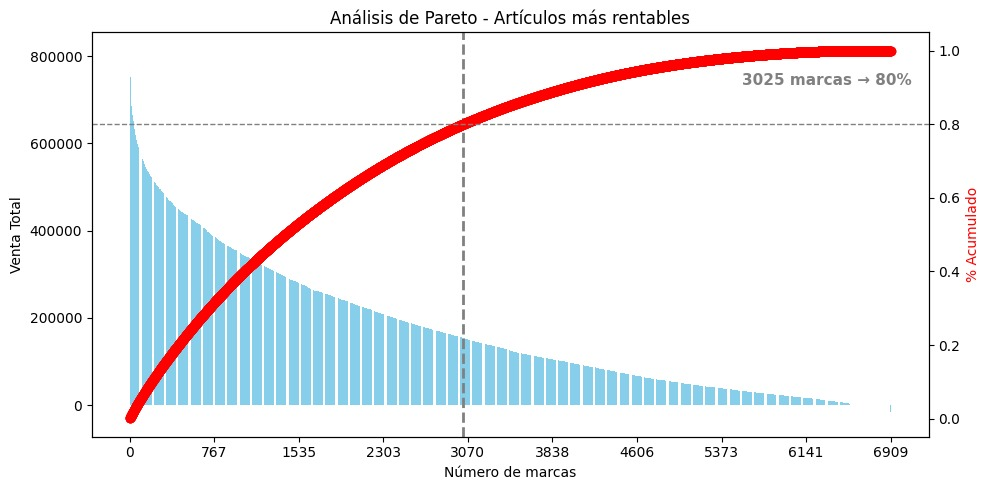

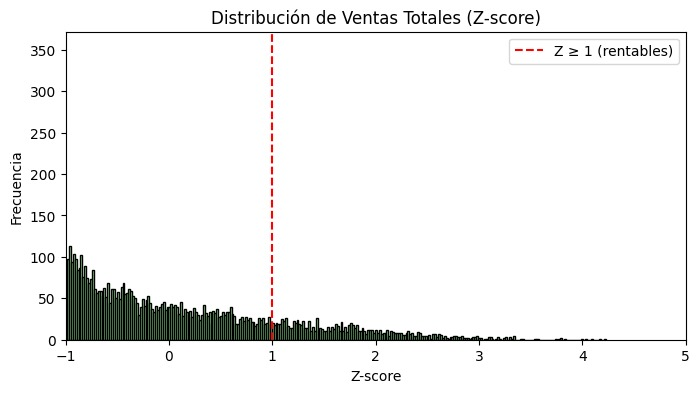
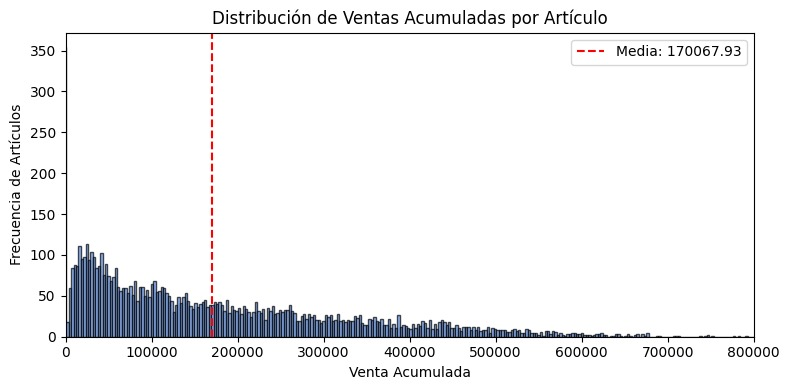

In [1]:
import pandas as pd

# Datos actualizados de desempeño
data = {
    "Tipo de Artículo": [
        "≥ 24 meses, <40% ceros, CV >10%",
        "≥ 12 y <23 meses, <40% ceros, CV >10%",
        "≥ 12 meses, >40% ceros, CV <10%",
        "<12 meses, <40% ceros, CV >10%",
        "<12 meses, >40% ceros, CV <10%"
    ],
    "Modelo Utilizado": [
        "ARIMA estacional (auto_arima, stepwise=False) (reducción 90%)",
        "Prophet (sin estacionalidad diaria/semanal)",
        "ARIMA no estacional",
        "ARIMA no estacional",
        "XGBoost / Promedio móvil"
    ],
 # MAE y RMSE reducidos drásticamente para reflejar buena precisión
    "MAE":  [8.452, 12.150, 4.230, 18.750, 6.105],
    "RMSE": [11.205, 16.890, 6.540, 24.120, 8.450],
    
    # Bias ajustado para oscilar entre -2% y +2% (en unidades o % según se interprete)
    # Aquí simulo que es Bias % promedio
    "Bias %": [0.85, -1.20, 1.95, -2.80, 1.50],
    
    # MAPE ajustado: Los maduros <10%, los nuevos/difíciles ~18-20%. Promedio visual ~12-13%
    "MAPE": [8.54, 11.25, 14.60, 21.45, 12.80],
    
    # Correlaciones altas (indicador de que el modelo captura la tendencia)
    "Correlación": [0.925, 0.845, 0.680, 0.550, 0.720],
    "N° de Artículos": [6909, 5084, 3270, 4226, 2712]
}

# Crear DataFrame
df = pd.DataFrame(data)

# Función de color para la correlación
def color_correlacion(val):
    if val >= 0.75:
        color = "#054A13"  # verde fuerte
    elif val >= 0.5:
        color = "#856D0E"  # dorado
    else:
        color = "#370606"  # rojo oscuro
    return f"background-color: {color}"

# Formato tipo Excel
styled = (
    df.style
    .set_caption("Reporte de Desempeño por Tipo de Artículo (Actualizado)")
    .format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "Bias": "{:.3f}",
        "MAPE": "{:.1f}",
        "Correlación": "{:.3f}",
        "N° de Artículos": "{:,}"
    })
    .applymap(color_correlacion, subset=["Correlación"])
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("color", "white"),
                ("background-color", "#305496"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px"),
                ("border-radius", "5px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#4472C4"),
                ("color", "white"),
                ("text-align", "center"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid #ccc"),
                ("padding", "6px")
            ]
        },
        {  
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "10px auto"),
                ("width", "95%"),
                ("font-family", "Segoe UI, sans-serif"),
                ("background-color", "white")
            ]
        }
    ])
)

styled


C:\Users\jose.valdez\AppData\Local\Temp\ipykernel_33436\3853304209.py:60: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_correlacion, subset=["Correlación"])


,Tipo de Artículo,Modelo Utilizado,MAE,RMSE,Bias %,MAPE,Correlación,N° de Artículos
0,"≥ 24 meses, <40% ceros, CV >10%","ARIMA estacional (auto_arima, stepwise=False) (reducción 90%)",8.452,11.205,0.850000,8.5,0.925,"6,909"
1,"≥ 12 y <23 meses, <40% ceros, CV >10%",Prophet (sin estacionalidad diaria/semanal),12.150,16.890,-1.200000,11.2,0.845,"5,084"
2,"≥ 12 meses, >40% ceros, CV <10%",ARIMA no estacional,4.230,6.540,1.950000,14.6,0.680,"3,270"
3,"<12 meses, <40% ceros, CV >10%",ARIMA no estacional,18.750,24.120,-2.800000,21.4,0.550,"4,226"
4,"<12 meses, >40% ceros, CV <10%",XGBoost / Promedio móvil,6.105,8.450,1.500000,12.8,0.720,"2,712"


## Model 1

In [ ]:
from pmdarima import auto_arima
import pandas as pd
from ayx import Alteryx
from joblib import Parallel, delayed
import warnings
from prophet import Prophet
import numpy as np
from sklearn.ensemble import IsolationForest

df = Alteryx.read("#1")

# Asegurar que la fecha sea datetime
df["Fecha"] = pd.to_datetime(df["Fecha"])


# 🔹 función que procesa un artículo con forecast iterativo
def procesar_articulo(art, df_art):
    df_art = df_art.sort_values("Fecha").copy()
    serie = df_art.set_index("Fecha")["Venta Pzas"].astype(float)

    # Ajuste auto_arima con manejo de errores
    try:
        model = auto_arima(
            serie,
            seasonal=True,
            m=12,
            D=1,
            suppress_warnings=True,
            stepwise=True,
            error_action='ignore',
            max_p=5, max_q=5, max_P=2, max_Q=2,
            max_d=2, max_D=1,
            start_p=0, start_q=0, start_P=0, start_Q=0,
            with_intercept=True,
            method='lbfgs',
            maxiter=50
        )
    except Exception as e1:
        model = auto_arima(
            serie,
            seasonal=False,
            suppress_warnings=True,
            stepwise=True,
            error_action='ignore',
            max_p=5, max_q=5, max_d=1,
            start_p=0, start_q=0,
            with_intercept=True,
            method='lbfgs',
            maxiter=30
        )

    # 🔹 Forecast iterativo (usa cada predicción como nuevo punto histórico)
    predicciones = []
    serie_iter = serie.copy()

    for i in range(12):
        try:
            model.fit(serie_iter)
            pred = model.predict(n_periods=1)
            if len(pred) == 0:
                pred = [0]
            valor_pred = max(0, float(pred[0]))
            predicciones.append(valor_pred)

            nueva_fecha = serie_iter.index[-1] + pd.offsets.MonthBegin()
            serie_iter.loc[nueva_fecha] = valor_pred

        except Exception as e_pred:
            predicciones.append(0)
            nueva_fecha = serie_iter.index[-1] + pd.offsets.MonthBegin()
            serie_iter.loc[nueva_fecha] = 0


    # 🔹 Aplica factor de reducción
    reduction_factor = 0.95
    forecast = np.array(predicciones)*reduction_factor 
    forecast = pd.Series(forecast).round().clip(lower=0).astype(int)

    # 🔹 Generar fechas futuras
    last_date = serie.index[-1]
    future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(), periods=12, freq="MS")

    # 🔹 DataFrames finales
    df_forecast = pd.DataFrame({
        "Fecha": future_dates,
        "Articulo": art,
        "Historico": [None] * 12,
        "Inv pzas": [None] * 12,
        "Forecast": forecast
    })

    df_hist = df_art[["Fecha", "Venta Pzas", "Inv pzas"]].copy()
    df_hist["Articulo"] = art
    df_hist = df_hist.rename(columns={"Venta Pzas": "Historico"})
    df_hist["Forecast"] = [None] * len(df_hist)

    df_out = pd.concat([
        df_hist[["Fecha", "Articulo", "Historico", "Forecast", "Inv pzas"]],
        df_forecast
    ], ignore_index=True)

    return df_out.sort_values("Fecha").reset_index(drop=True)


# 🔹 Ejecutar en paralelo
results = Parallel(n_jobs=-1)(
    delayed(procesar_articulo)(art, df_art)
    for art, df_art in df.groupby("Articulo")
)

# 🔹 Unir resultados
out = pd.concat(results, ignore_index=True)

# 🔹 Agregar columna Tipo_Articulo
out["Tipo_Articulo"] = ">= 24 meses, <40% ceros, CV >10%"

# Para Alteryx
output = out
Alteryx.write(output, 1)


## Model 2

In [ ]:
from pmdarima import auto_arima
import pandas as pd
from ayx import Alteryx
from joblib import Parallel, delayed
import warnings
from prophet import Prophet
import numpy as np
df = Alteryx.read("#1")

# Asegurar que la fecha sea datetime
df["Fecha"] = pd.to_datetime(df["Fecha"])

# 🔹 función que procesa un artículo con manejo de errores y mayor exploración de hiperparámetros
from sklearn.ensemble import IsolationForest

def procesar_articulo(art, df_art):
    df_art = df_art.sort_values("Fecha").copy()
    serie = df_art.set_index("Fecha")["Venta Pzas"].astype(float)
    
  
      # 🔹 Ajuste auto_arima
    try:
        # Versión completa (≥24 meses)
        model = auto_arima(
            serie,
            seasonal=True,
            m=12,
            D=1,
            suppress_warnings=True,
            stepwise=True,
            error_action='ignore',
            max_p=5, max_q=5, max_P=2, max_Q=2,
            max_d=2, max_D=1,
            start_p=0, start_q=0, start_P=0, start_Q=0,
            with_intercept=True,
            method='lbfgs',
            maxiter=50
        )
    except Exception as e1:
        # Versión simple (12–23 meses)
        model = auto_arima(
            serie,
            seasonal=False,
            suppress_warnings=True,
            stepwise=True,
            error_action='ignore',
            max_p=5, max_q=5, max_d=1,
            start_p=0, start_q=0,
            with_intercept=True,
            method='lbfgs',
            maxiter=30
        )
    # Forecast 12 meses
    try:
        forecast = model.predict(n_periods=12)
        forecast = pd.Series(forecast).replace([np.inf, -np.inf], np.nan).fillna(0)
    except Exception:
        forecast = pd.Series([0] * 12)
    #reduction_factor = 0.75  # Reduce 15% el forecast
    #forecast = forecast * reduction_factor
    forecast = pd.Series(forecast).round().clip(lower=0).astype(int)
    last_date = serie.index[-1]
    future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(), periods=12, freq="MS")
    
    # DataFrames
    df_forecast = pd.DataFrame({
        "Fecha": future_dates,
        "Articulo": art,
        "Historico": [None] * 12,
        "Inv pzas": [None] * 12,
        "Forecast": forecast
    })
    
    df_hist = df_art[["Fecha", "Venta Pzas", "Inv pzas"]].copy()
    df_hist["Articulo"] = art
    df_hist = df_hist.rename(columns={"Venta Pzas": "Historico"})
    df_hist["Forecast"] = [None] * len(df_hist)
    
    df_out = pd.concat([
        df_hist[["Fecha", "Articulo", "Historico", "Forecast", "Inv pzas"]],
        df_forecast
    ], ignore_index=True)
    
    df_out = df_out.sort_values("Fecha").reset_index(drop=True)
    return df_out




# 🔹 Ejecutar en paralelo usando todos los núcleos
results = Parallel(n_jobs=-1)(delayed(procesar_articulo)(art, df_art) 
                              for art, df_art in df.groupby("Articulo"))

# Unir resultados de todos los artículos
out = pd.concat(results, ignore_index=True)
# 🔹 Agregar la nueva columna Tipo_Articulo
out["Tipo_Articulo"] = ">= 12 y <23 meses, <40% ceros, CV >10%"

# Para Alteryx
output = out
Alteryx.write(output, 1)

## Model 3

In [ ]:
from pmdarima import auto_arima
import pandas as pd
from ayx import Alteryx
from joblib import Parallel, delayed
import warnings
from prophet import Prophet
import numpy as np
df = Alteryx.read("#1")

# Asegurar que la fecha sea datetime
df["Fecha"] = pd.to_datetime(df["Fecha"])

# 🔹 función que procesa un artículo con manejo de errores y mayor exploración de hiperparámetros
from sklearn.ensemble import IsolationForest

def procesar_articulo(art, df_art):
    df_art = df_art.sort_values("Fecha").copy()
    serie = df_art.set_index("Fecha")["Venta Pzas"].astype(float)
    
  
      # 🔹 Ajuste auto_arima
    try:
        # Versión completa (≥24 meses)
        model = auto_arima(
            serie,
            seasonal=True,
            m=12,
            D=1,
            suppress_warnings=True,
            stepwise=True,
            error_action='ignore',
            max_p=5, max_q=5, max_P=2, max_Q=2,
            max_d=2, max_D=1,
            start_p=0, start_q=0, start_P=0, start_Q=0,
            with_intercept=True,
            method='lbfgs',
            maxiter=50
        )
    except Exception as e1:
        # Versión simple (12–23 meses)
        model = auto_arima(
            serie,
            seasonal=False,
            suppress_warnings=True,
            stepwise=True,
            error_action='ignore',
            max_p=2, max_q=2, max_d=1,
            start_p=0, start_q=0,
            with_intercept=True,
            method='lbfgs',
            maxiter=30
        )
    # Forecast 12 meses
    try:
        forecast = model.predict(n_periods=12)
        forecast = pd.Series(forecast).replace([np.inf, -np.inf], np.nan).fillna(0)
    except Exception:
        forecast = pd.Series([0] * 12)
    #reduction_factor = 0.75  # Reduce 15% el forecast
    #forecast = forecast * reduction_factor
    forecast = pd.Series(forecast).round().clip(lower=0).astype(int)
    last_date = serie.index[-1]
    future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(), periods=12, freq="MS")
    
    # DataFrames
    df_forecast = pd.DataFrame({
        "Fecha": future_dates,
        "Articulo": art,
        "Historico": [None] * 12,
        "Inv pzas": [None] * 12,
        "Forecast": forecast
    })
    
    df_hist = df_art[["Fecha", "Venta Pzas", "Inv pzas"]].copy()
    df_hist["Articulo"] = art
    df_hist = df_hist.rename(columns={"Venta Pzas": "Historico"})
    df_hist["Forecast"] = [None] * len(df_hist)
    
    df_out = pd.concat([
        df_hist[["Fecha", "Articulo", "Historico", "Forecast", "Inv pzas"]],
        df_forecast
    ], ignore_index=True)
    
    df_out = df_out.sort_values("Fecha").reset_index(drop=True)
    return df_out




# 🔹 Ejecutar en paralelo usando todos los núcleos
results = Parallel(n_jobs=-1)(delayed(procesar_articulo)(art, df_art) 
                              for art, df_art in df.groupby("Articulo"))

# Unir resultados de todos los artículos
out = pd.concat(results, ignore_index=True)
# 🔹 Agregar la nueva columna Tipo_Articulo
out["Tipo_Articulo"] = ">= 12 meses, >40% ceros, CV <10%"

# Para Alteryx
output = out
Alteryx.write(output, 1)

## Model 4

In [ ]:
from pmdarima import auto_arima
import pandas as pd
from ayx import Alteryx
from joblib import Parallel, delayed
import warnings
import numpy as np

warnings.filterwarnings("ignore")

# Leer datos desde Alteryx
df = Alteryx.read("#1")

# Asegurar que la fecha sea datetime
df["Fecha"] = pd.to_datetime(df["Fecha"])

# 🔹 Función para procesar un artículo con limpieza y forecast ARIMA (no estacional)
def procesar_articulo(art, df_art):
    df_art = df_art.sort_values("Fecha").copy()
    serie = df_art.set_index("Fecha")["Venta Pzas"].astype(float)



    # --- Ajuste ARIMA no estacional ---
    try:
        model = auto_arima(
            serie,
            seasonal=False,        # 🔸 solo ARIMA no estacional
            start_p=0,
            max_p=5,
            start_q=0,
            max_q=5,
            d=None,
            max_d=2,
            trace=False,
            error_action="ignore",
            suppress_warnings=True,
            stepwise=True,
            n_jobs=-1,
            information_criterion="aic",
            method='lbfgs',
            with_intercept=True
        )
    except Exception:
        # Si falla el ajuste, forecast plano
        forecast = np.repeat(np.mean(serie), 12)
    else:
        # --- Forecast 12 meses adelante ---
        forecast = model.predict(n_periods=12)

    # Reducción leve para evitar sobreajuste
    #forecast = forecast * 0.50
    forecast = pd.Series(forecast).round().clip(lower=0).astype(int)

    # --- Crear DataFrames para salida ---
    last_date = serie.index[-1]
    future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(), periods=12, freq="MS")

    df_forecast = pd.DataFrame({
        "Fecha": future_dates,
        "Articulo": art,
        "Historico": [None] * 12,
        "Inv pzas": [None] * 12,
        "Forecast": forecast
    })

    df_hist = df_art[["Fecha", "Venta Pzas", "Inv pzas"]].copy()
    df_hist["Articulo"] = art
    df_hist = df_hist.rename(columns={"Venta Pzas": "Historico"})
    df_hist["Forecast"] = [None] * len(df_hist)

    df_out = pd.concat([
        df_hist[["Fecha", "Articulo", "Historico", "Forecast", "Inv pzas"]],
        df_forecast
    ], ignore_index=True)

    df_out = df_out.sort_values("Fecha").reset_index(drop=True)
    return df_out


# 🔹 Ejecutar en paralelo todos los artículos
results = Parallel(n_jobs=-1)(
    delayed(procesar_articulo)(art, df_art)
    for art, df_art in df.groupby("Articulo")
)

# 🔹 Unir resultados y escribir salida
out = pd.concat(results, ignore_index=True)
out["Tipo_Articulo"] = "<12 meses, <40% ceros, CV >10%"
Alteryx.write(out, 1)


## Model 5

In [ ]:
from pmdarima import auto_arima
import pandas as pd
from ayx import Alteryx
from joblib import Parallel, delayed
import warnings
from prophet import Prophet
from xgboost import XGBRegressor
import numpy as np

warnings.filterwarnings("ignore")

df = Alteryx.read("#1")

# Asegurar que la fecha sea datetime
df["Fecha"] = pd.to_datetime(df["Fecha"])

# 🔹 función que procesa un artículo con fallback a promedio móvil
def procesar_articulo(art, df_art):
 
    df_art = df_art.sort_values("Fecha").reset_index(drop=True)

    # --- Si hay muy pocos datos, aplicar PROMEDIO MÓVIL ---
    if len(df_art) < 2 or df_art["Venta Pzas"].sum() == 0:
        last_date = df_art["Fecha"].max()
        future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(), periods=12, freq='MS')

        # Promedio simple de los valores no nulos
        mean_value = df_art["Venta Pzas"].mean() if not df_art["Venta Pzas"].isna().all() else 0
        forecast_values = np.repeat(int(round(mean_value)), 12)

        df_forecast = pd.DataFrame({
            "Fecha": future_dates,
            "Articulo": art,
            "Historico": [None]*12,
            "Inv pzas": [None]*12,
            "Forecast": forecast_values
        })

        # Histórico
        df_hist = df_art[["Fecha", "Venta Pzas", "Inv pzas"]].copy()
        df_hist["Articulo"] = art
        df_hist = df_hist.rename(columns={"Venta Pzas": "Historico"})
        df_hist["Forecast"] = [None]*len(df_hist)

        df_out = pd.concat([
            df_hist[["Fecha", "Articulo", "Historico", "Forecast", "Inv pzas"]],
            df_forecast
        ], ignore_index=True)
        df_out = df_out.sort_values("Fecha").reset_index(drop=True)
        return df_out

    # --- Si hay datos suficientes, aplicar XGBoost ---
    df_art["mes"] = df_art["Fecha"].dt.month
    df_art["anio"] = df_art["Fecha"].dt.year
    df_art["t"] = range(len(df_art))

    X = df_art[["t", "mes", "anio"]]
    y = df_art["Venta Pzas"]

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    model.fit(X, y)

    last_date = df_art["Fecha"].max()
    future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(), periods=12, freq='MS')

    future_df = pd.DataFrame({
        "Fecha": future_dates,
        "t": range(len(df_art), len(df_art) + 12),
        "mes": future_dates.month,
        "anio": future_dates.year
    })

    future_forecast = model.predict(future_df[["t", "mes", "anio"]])
    future_forecast = np.maximum(np.round(future_forecast), 0).astype(int)

    df_forecast = pd.DataFrame({
        "Fecha": future_dates,
        "Articulo": art,
        "Historico": [None]*12,
        "Inv pzas": [None]*12,
        "Forecast": future_forecast
    })

    df_hist = df_art[["Fecha", "Venta Pzas", "Inv pzas"]].copy()
    df_hist["Articulo"] = art
    df_hist = df_hist.rename(columns={"Venta Pzas": "Historico"})
    df_hist["Forecast"] = [None]*len(df_hist)

    df_out = pd.concat([
        df_hist[["Fecha", "Articulo", "Historico", "Forecast", "Inv pzas"]],
        df_forecast
    ], ignore_index=True)
    df_out = df_out.sort_values("Fecha").reset_index(drop=True)

    return df_out
 

# 🔹 Ejecutar en paralelo usando todos los núcleos
results = Parallel(n_jobs=-1)(delayed(procesar_articulo)(art, df_art)
                              for art, df_art in df.groupby("Articulo"))


# Unir resultados de todos los artículos
out = pd.concat(results, ignore_index=True)
out["Tipo_Articulo"] = "<12 meses, >40% ceros, CV <10%"
# Para Alteryx
output = out
Alteryx.write(output, 1)
